In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pathlib
from tensorflow.keras import regularizers
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

'/root/.keras/datasets/flower_photos'

In [ ]:
data_dir = pathlib.Path("/root/.keras/datasets/flower_photos/flower_photos")

image_count = len(list(data_dir.glob("*/*.jpg")))

print("Total Images:", image_count)

Total Images: 3670


In [ ]:
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
class_names = train_ds.class_names

print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


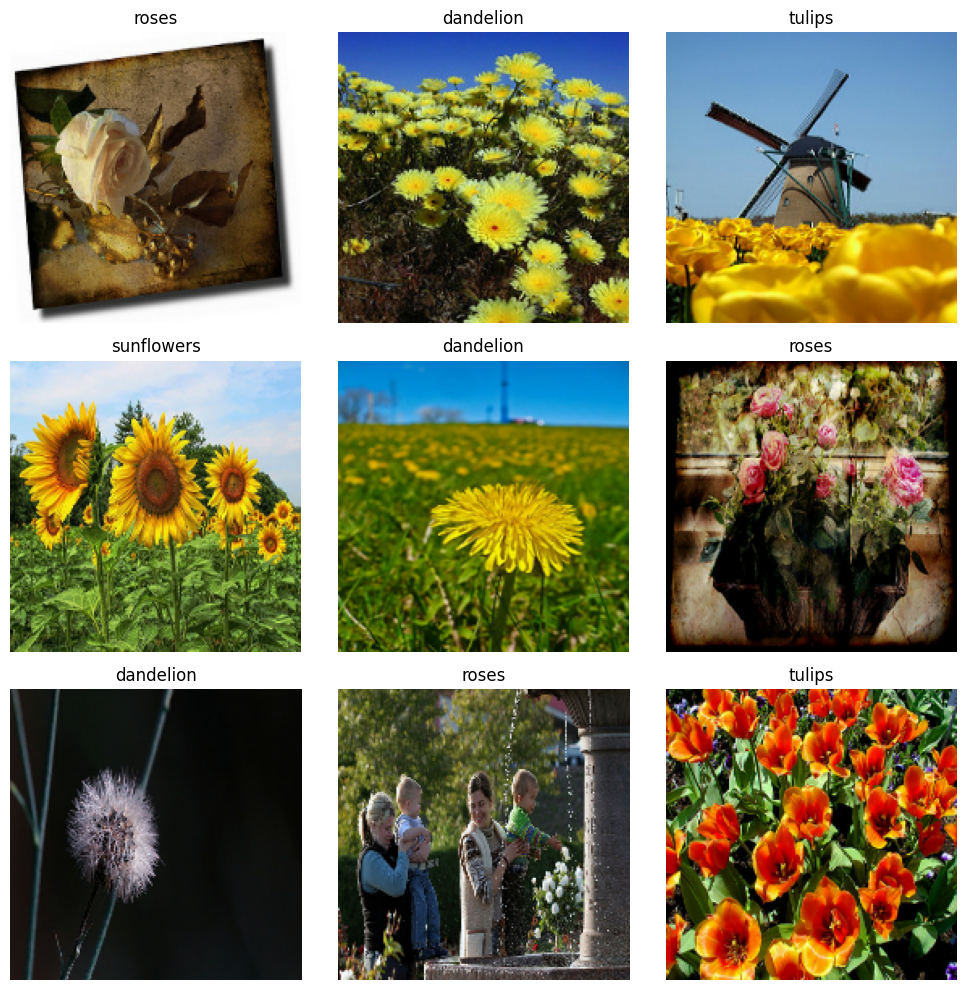

In [ ]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomContrast(0.2),

    layers.RandomTranslation(0.1, 0.1)

])

In [ ]:
model = models.Sequential([

    layers.Input(shape=(180,180,3)),

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32,3,padding="same",activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,padding="same",activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,padding="same",activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Dropout(0.35),

    layers.Flatten(),

    layers.Dense(256,activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(5,activation="softmax")

])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=6,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_flower_model.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

In [ ]:
model.save("flower_classifier.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4195 - loss: 2.1530
Epoch 1: val_accuracy improved from None to 0.23978, saving model to best_flower_model.keras

Epoch 1: finished saving model to best_flower_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.4751 - loss: 1.7013 - val_accuracy: 0.2398 - val_loss: 3.7549 - learning_rate: 0.0010
Epoch 2/30
20/92 ━━━━━━━━━━━━━━━━━━━━ 2:38 2s/step - accuracy: 0.5506 - loss: 1.2820

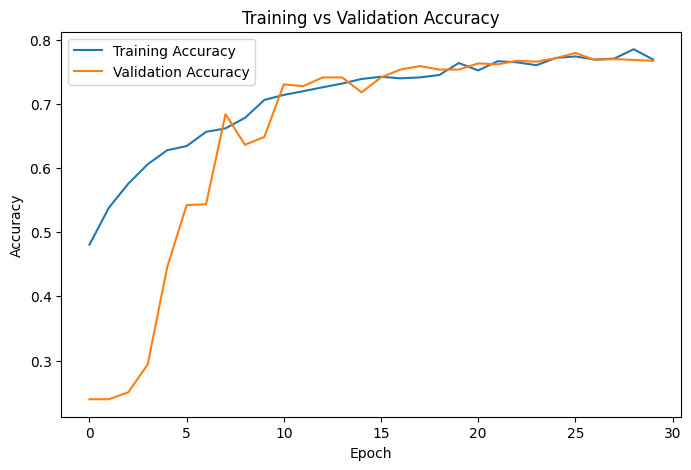

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig("accuracy.png")

plt.show()

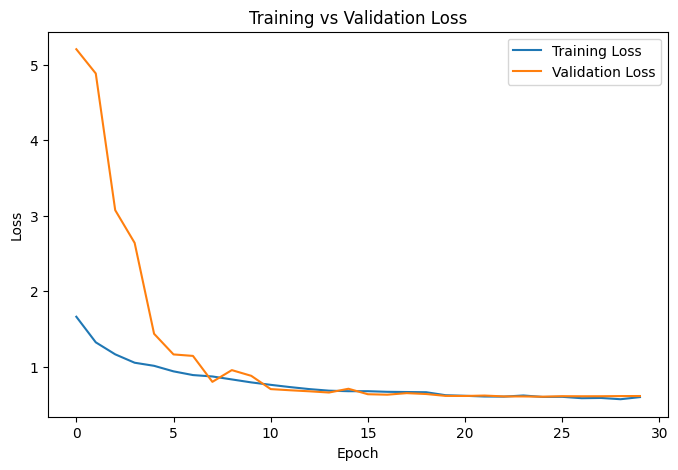

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig("loss.png")

plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.7793 - loss: 0.6074
Validation Accuracy: 0.779291570186615
Validation Loss: 0.6074317097663879


In [ ]:
model.save("flower_cnn_model.keras")

In [ ]:
from google.colab import files

files.download("flower_cnn_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

y_true = np.concatenate([y for x, y in val_ds], axis=0)

predictions = model.predict(val_ds)

y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

classes = ["Daisy","Dandelion","Roses","Sunflowers","Tulips"]

plt.xticks(range(5), classes, rotation=45)
plt.yticks(range(5), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for images, labels in val_ds.take(1):

    predictions = model.predict(images)

    predicted = np.argmax(predictions, axis=1)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(f"P:{class_names[predicted[i]]}")

        plt.axis("off")

plt.savefig("sample_predictions.png")

plt.show()

NameError: name 'plt' is not defined